# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  https://www.kaggle.com/datasets/therohithanand/used-car-price-prediction
   


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [5]:
#import library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import warnings

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [6]:
df = pd.read_csv('used_car_price_dataset_extended.csv')
df.head()

,make_year,mileage_kmpl,engine_cc,fuel_type,owner_count,price_usd,brand,transmission,color,service_history,accidents_reported,insurance_valid
0,2001,8.17,4000,Petrol,4,8587.64,Chevrolet,Manual,White,NaN,0,No
1,2014,17.59,1500,Petrol,4,5943.50,Honda,Manual,Black,NaN,0,Yes
2,2023,18.09,2500,Diesel,5,9273.58,BMW,Automatic,Black,Full,1,Yes
3,2009,11.28,800,Petrol,1,6836.24,Hyundai,Manual,Blue,Full,0,Yes
4,2005,12.23,1000,Petrol,2,4625.79,Nissan,Automatic,Red,Full,0,Yes


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [7]:
# Informasi Dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   make_year           10000 non-null  int64  
 1   mileage_kmpl        10000 non-null  float64
 2   engine_cc           10000 non-null  int64  
 3   fuel_type           10000 non-null  object 
 4   owner_count         10000 non-null  int64  
 5   price_usd           10000 non-null  float64
 6   brand               10000 non-null  object 
 7   transmission        10000 non-null  object 
 8   color               10000 non-null  object 
 9   service_history     7962 non-null   object 
 10  accidents_reported  10000 non-null  int64  
 11  insurance_valid     10000 non-null  object 
dtypes: float64(2), int64(4), object(6)
memory usage: 937.6+ KB


In [8]:
#Menampilkan statistik deskriptif dataset
df.describe()

,make_year,mileage_kmpl,engine_cc,owner_count,price_usd,accidents_reported
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,2009.206900,17.960753,2287.130000,3.003500,7179.754532,0.492200
std,8.373858,5.025486,1291.276927,1.418904,2795.270940,0.694109
min,1995.000000,5.000000,800.000000,1.000000,1000.000000,0.000000
25%,2002.000000,14.540000,1200.000000,2.000000,5176.547500,0.000000
50%,2009.000000,17.970000,1800.000000,3.000000,6961.260000,0.000000
75%,2016.000000,21.352500,3000.000000,4.000000,8993.732500,1.000000
max,2023.000000,35.000000,5000.000000,5.000000,17647.630000,5.000000


In [9]:
# Cek missing value dan duplicated

print("\n=== MISSING VALUES ===")
print(df.isnull().sum())

print("\n=== DUPLICATED ROWS ===")
print("Duplicates:", df.duplicated().sum())


=== MISSING VALUES ===
make_year                0
mileage_kmpl             0
engine_cc                0
fuel_type                0
owner_count              0
price_usd                0
brand                    0
transmission             0
color                    0
service_history       2038
accidents_reported       0
insurance_valid          0
dtype: int64

=== DUPLICATED ROWS ===
Duplicates: 0


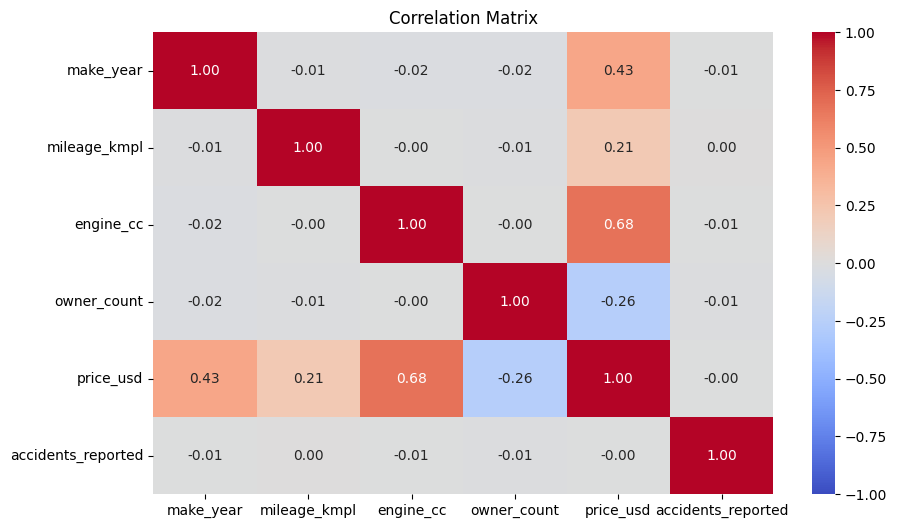

In [10]:
# Menampilkan korelasi antar fitur

# Memilih kolom numerik
numerical_cols = df.select_dtypes(include=['number']).columns

### MULAI CODE ###

# Hitung matriks korelasi
correlation = df[numerical_cols].corr()

# Buat visualisasi heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(correlation,
               annot=True,
               cmap='coolwarm',
               fmt=".2f",
               vmin=-1,
               vmax=1)
plt.title('Correlation Matrix')
plt.show()

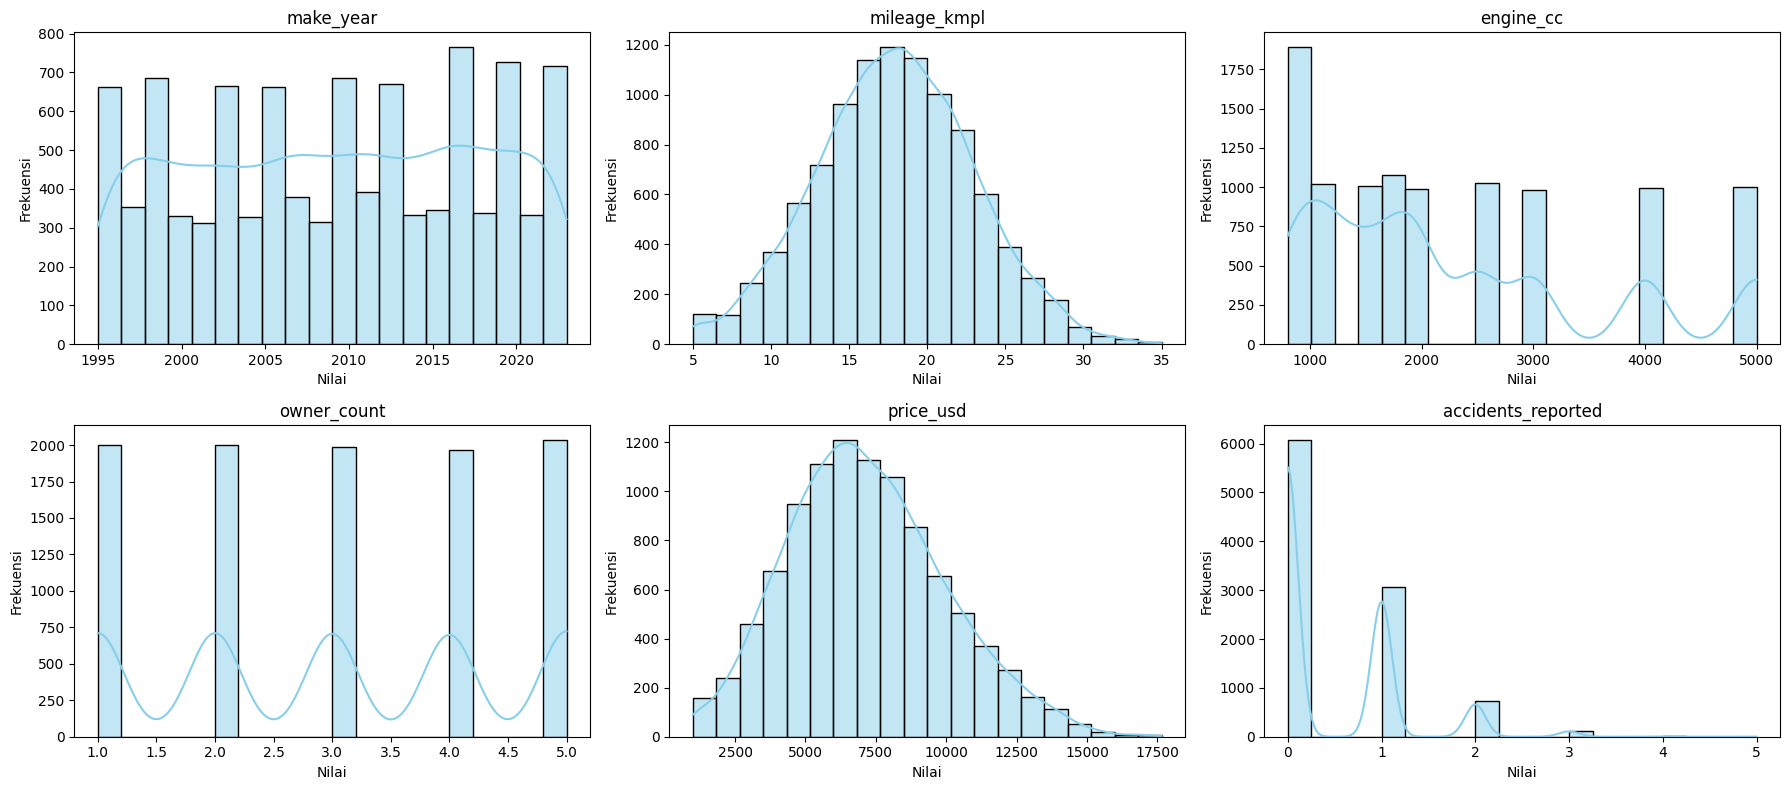

In [11]:
# Menampilkan histogram untuk semua kolom numerik

fig, axes = plt.subplots(2, 3, figsize=(18, 8))
axes = axes.flatten()

for i, column in enumerate(numerical_cols):

    # Tampilkan histogram dan pastikan plot ditempatkan di subplot (axes) yang benar
    sns.histplot(df[column], bins=20, kde=True, color='skyblue', ax=axes[i])

    # Atur judul dan label
    axes[i].set_title(column)
    axes[i].set_xlabel("Nilai")
    axes[i].set_ylabel("Frekuensi")


plt.tight_layout()
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [12]:
# Menangani missing value
df.dropna(inplace=True)

# Cek kembali dataset menggunakan isnull().sum()
df.isnull().sum()

,0
make_year,0
mileage_kmpl,0
engine_cc,0
fuel_type,0
owner_count,0
price_usd,0
brand,0
transmission,0
color,0
service_history,0


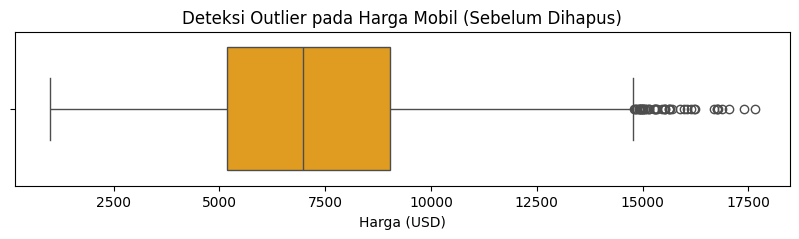

Batas harga wajar: $-592.10 sampai $14792.95
Jumlah baris SEBELUM outlier dihapus: 7962
Jumlah baris SETELAH outlier dihapus: 7916
Total baris outlier yang dibuang: 46



In [13]:
# VISUALISASI OUTLIER (Sebelum Dihapus)
plt.figure(figsize=(10, 2))
sns.boxplot(x=df['price_usd'], color='orange')
plt.title('Deteksi Outlier pada Harga Mobil (Sebelum Dihapus)')
plt.xlabel('Harga (USD)')
plt.show()

# MENGHAPUS OUTLIER DENGAN METODE IQR
# Menghitung Kuartil 1 (Q1) dan Kuartil 3 (Q3)
Q1 = df['price_usd'].quantile(0.25)
Q3 = df['price_usd'].quantile(0.75)
IQR = Q3 - Q1

# Menentukan batas bawah dan batas atas harga yang "wajar"
batas_bawah = Q1 - 1.5 * IQR
batas_atas = Q3 + 1.5 * IQR

print(f"Batas harga wajar: ${batas_bawah:.2f} sampai ${batas_atas:.2f}")

# Menyaring dataframe agar hanya berisi harga yang masuk akal
df_bersih = df[(df['price_usd'] >= batas_bawah) & (df['price_usd'] <= batas_atas)]

print(f"Jumlah baris SEBELUM outlier dihapus: {len(df)}")
print(f"Jumlah baris SETELAH outlier dihapus: {len(df_bersih)}")
print(f"Total baris outlier yang dibuang: {len(df) - len(df_bersih)}\n")

In [16]:
# Melakukan feature encoding menggunakan LabelEncoder() untuk fitur kategorikal.
# Pastikan kamu menggunakan function head setelah melalukan encoding.

# Pilih semua kolom yang bertipe 'object' (kategorikal)
categorical_cols = list(df_bersih.select_dtypes(include=['object']).columns)

encoders = {}

# Loop melalui setiap kolom kategorikal
for column in categorical_cols:
    # Buat (instantiate) objek LabelEncoder
    label_encoder = LabelEncoder()

    # Terapkan (fit) encoder ke data dan sekaligus ubah (transform) data tersebut
    df_bersih[column] = label_encoder.fit_transform(df_bersih[column])

    # Simpan encoder
    encoders[column] = label_encoder

# Tampilkan 5 baris pertama untuk memverifikasi hasil encoding
df_bersih.head()


/tmp/ipykernel_2085/1369373147.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_bersih[column] = label_encoder.fit_transform(df_bersih[column])
/tmp/ipykernel_2085/1369373147.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_bersih[column] = label_encoder.fit_transform(df_bersih[column])
/tmp/ipykernel_2085/1369373147.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the 

,make_year,mileage_kmpl,engine_cc,fuel_type,owner_count,price_usd,brand,transmission,color,service_history,accidents_reported,insurance_valid
2,2023,18.09,2500,0,5,9273.58,0,0,0,0,1,1
3,2009,11.28,800,2,1,6836.24,4,1,1,0,0,1
4,2005,12.23,1000,2,2,4625.79,6,0,3,0,0,1
5,2002,13.77,2500,0,4,6856.03,0,1,2,0,1,1
6,2023,12.50,1000,2,3,6806.77,0,1,3,0,0,1


In [17]:
# 1. MEMISAHKAN FITUR (X) DAN TARGET (y)
y = df_bersih['price_usd']
X = df_bersih.drop(columns=['price_usd'])

# 2. TRAIN-TEST SPLIT (Bagi Data DULU)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. PROSES STANDARISASI FITUR (Scaling)
scaler = StandardScaler()

# Fit & Transform hanya pada data Train (X_train)
X_train_scaled = scaler.fit_transform(X_train)
# HANYA Transform pada data Test (X_test)
X_test_scaled = scaler.transform(X_test)

# Kembalikan ke format DataFrame agar rapi
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

# 4. GABUNGKAN KEMBALI X DAN y
df_train_ready = X_train_scaled.copy()
df_train_ready['price_usd'] = y_train.values  # Gunakan .values agar urutan baris tidak berantakan

df_test_ready = X_test_scaled.copy()
df_test_ready['price_usd'] = y_test.values

# 5. SIMPAN KE CSV
df_train_ready.to_csv('data_train_bersih.csv', index=False)
df_test_ready.to_csv('data_test_bersih.csv', index=False)

print("=== PROSES PERSIAPAN DATA SELESAI! ===")
print("Data berhasil distandarisasi dan disimpan:")
print(f"- 'data_train_bersih.csv' ({df_train_ready.shape[0]} baris)")
print(f"- 'data_test_bersih.csv' ({df_test_ready.shape[0]} baris)")


=== PROSES PERSIAPAN DATA SELESAI! ===
Data berhasil distandarisasi dan disimpan:
- 'data_train_bersih.csv' (6332 baris)
- 'data_test_bersih.csv' (1584 baris)
